In [7]:
# %matplotlib inline
%matplotlib widget

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy

from tqdm import tqdm
from docx import Document
from docx.shared import Inches
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT, WD_ALIGN_PARAGRAPH

import Flexivan_Prediction_Package

In [2]:
# Get filenames from folder
print('Getting PAST raw data filenames...')
DATA_Folder = '/root/Flexivan/Flexivan/Daily prediction/DATA'

FILENAMES = [f for f in os.listdir(DATA_Folder) if os.path.isfile(os.path.join(DATA_Folder, f))]
selected = "Latest_Test_"
selected2 = '_DETAILED'
FILENAMES = [f for f in FILENAMES if selected in f and selected2 not in f]
DATES = Flexivan_Prediction_Package.extract_datetimes_from_filenames(FILENAMES)
Filenames_DF = pd.DataFrame({
    "Filenames": FILENAMES,
    "Dates": DATES
})
Filenames_DF_Sorted = Filenames_DF.sort_values(by='Dates')
FILENAMES = list(Filenames_DF_Sorted['Filenames'])
DATES = list(Filenames_DF_Sorted['Dates'])

print(f'DONE - {len(FILENAMES)} Filenames were found')


#endregion


Getting PAST raw data filenames...
DONE - 250 Filenames were found


In [3]:
DATA = pd.read_csv(f'{DATA_Folder}/{FILENAMES[0]}')
DATA.columns

Index(['CHS ID', 'CHS Pickup Loc', 'CHS Return Loc', 'CHS Pickup Date',
       'CHS Return Dt', 'CHS pickup MCO', 'CHS pickup MCO.1', 'Customer',
       'CTR Trip Pattern', 'DC Loc', 'CTR pick Dt', 'CTR Return Dt',
       'CTR Trip Hrs', 'CTR Pickup Term', 'CTR Return Term', 'CHS Trip Hrs',
       'CTR Trip Loc Type Pattern', 'On Street Count', 'Total CTR Trips'],
      dtype='object')

In [4]:
# # Collect PUs sums from files

# PUs_Quants_per_Day_by_LOT = {}
# Pickup_LOT_Field_Name = 'CHS Pickup Loc'

# print(f'Collecting PUs quantities from all {len(FILENAMES)} data file per lot...')

# for filename in tqdm(FILENAMES):
#     DATA = pd.read_csv(f'{DATA_Folder}/{filename}')

#     PU_Lots_Unique = list(DATA[Pickup_LOT_Field_Name].unique())

#     for pu_lot in PU_Lots_Unique:
#         DATA_TEMP = DATA[DATA[Pickup_LOT_Field_Name]==pu_lot]

#         try:
#             PUs_Quants_per_Day_by_LOT[pu_lot]
#         except:
#             PUs_Quants_per_Day_by_LOT[pu_lot] = []

#         PUs_Quants_per_Day_by_LOT[pu_lot].append(len(DATA_TEMP))

# # Calculating sums for final report percentages display
# print('Calculating sums...', end='')
# PUs_SUMS_DICT = {}
# for pu_lot in PUs_Quants_per_Day_by_LOT.keys():
#     PUs_SUMS_DICT[pu_lot] = sum(PUs_Quants_per_Day_by_LOT[pu_lot])
    
# print('DONE.')

In [4]:
# Collect PUs sums from files by dates (different dates appear in date files. Generate date baskets with sums collected from files and then
# treat those as if they were files f a single date so code will be consistent)

PUs_Quants_per_Day_by_LOT = {}
Pickup_LOT_Field_Name = 'CHS Pickup Loc'
Pickup_Date_Filed_Name = 'CHS Pickup Date'

print(f'Collecting PUs quantities from all {len(FILENAMES)} data file per lot...')
filename_index = 0

for filename in FILENAMES:
    DATA = pd.read_csv(f'{DATA_Folder}/{filename}')

    PU_Lots_Unique = list(DATA[Pickup_LOT_Field_Name].unique())

    for pu_lot_index, pu_lot in enumerate(PU_Lots_Unique):
        DATA_TEMP = DATA[DATA[Pickup_LOT_Field_Name]==pu_lot]

        try:
            PUs_Quants_per_Day_by_LOT[pu_lot]
        except:
            PUs_Quants_per_Day_by_LOT[pu_lot] = {}

        DATA_TEMP[Pickup_Date_Filed_Name] = pd.to_datetime(DATA_TEMP[Pickup_Date_Filed_Name])
        DATA_TEMP[Pickup_Date_Filed_Name] = DATA_TEMP[Pickup_Date_Filed_Name].dt.date
        Dates_Unique = list(DATA_TEMP[Pickup_Date_Filed_Name].unique())

        for DATE_index, DATE in enumerate(Dates_Unique):
            print(f'Filename No.{filename_index+1} out of {len(FILENAMES)} - LOT No.{pu_lot_index+1} out of {len(PU_Lots_Unique)} - Date No.{DATE_index+1} out of {len(Dates_Unique)}', end='\r')
            DATA_TEMP_date = DATA_TEMP[DATA_TEMP[Pickup_Date_Filed_Name]==DATE]

            try:
                PUs_Quants_per_Day_by_LOT[pu_lot][DATE]
            except:
                PUs_Quants_per_Day_by_LOT[pu_lot][DATE] = 0
            
            PUs_Quants_per_Day_by_LOT[pu_lot][DATE] += len(DATA_TEMP_date)

    filename_index += 1

# Turn PUs_Quants_per_Day_by_LOT from a DICT of DICTs into lists of sorted sums by date
PUs_Quants_per_Day_by_LOT = copy.deepcopy(PUs_Quants_per_Day_by_LOT)

for pu_lot in PUs_Quants_per_Day_by_LOT.keys():
    PUs_Quants_per_Day_by_LOT[pu_lot] = dict(sorted(PUs_Quants_per_Day_by_LOT[pu_lot].items()))
    PUs_Quants_per_Day_by_LOT[pu_lot] = list(PUs_Quants_per_Day_by_LOT[pu_lot].values())
    print(f'{pu_lot} - {PUs_Quants_per_Day_by_LOT[pu_lot]}')
    
# Calculating sums for final report percentages display
print('Calculating sums...', end='')
PUs_SUMS_DICT = {}
for pu_lot in PUs_Quants_per_Day_by_LOT.keys():
    PUs_SUMS_DICT[pu_lot] = sum(PUs_Quants_per_Day_by_LOT[pu_lot])

print('DONE.')


LAXAIM - [74, 167, 90, 13, 22, 92, 274, 95, 27, 66, 3, 94, 14, 28, 41, 91, 65, 73, 13, 56, 53, 100, 38, 96, 39, 245, 11, 8, 60, 55, 49, 14, 26, 58, 3, 9, 3, 29, 8, 18, 30, 44, 49, 19, 13, 86, 16, 7, 7, 21, 1, 14, 17, 42, 13, 40, 25, 12, 12, 20, 10, 5, 102, 15, 9, 5, 41, 2, 42, 6, 7, 6, 15, 44, 64, 41, 3, 11, 22, 17, 6, 8, 18, 7, 26, 29, 3, 29, 4, 52, 14, 30, 7, 35, 13, 51, 1, 40, 7, 8, 37, 24, 6, 20, 87, 21, 17, 38, 33, 26, 6, 9, 44, 21, 18, 8, 130, 200, 80, 44, 89, 1, 35, 68, 101, 60, 62, 2, 32, 14, 26, 53, 41, 3, 15, 18, 19, 142, 54, 113, 106, 65, 63, 137, 196, 118, 139, 183, 58, 104, 134, 164, 48, 52, 87, 84, 35, 45, 38, 87, 62, 31, 17, 80, 215, 169, 189, 42, 115, 104, 106, 171, 123, 46, 134, 97, 91, 122, 152, 172, 339, 110, 166, 217, 51, 43, 114, 35, 3, 72, 18, 72, 54, 134, 45, 2, 31, 68, 87, 5, 13, 30, 97, 102, 61, 19, 336, 218, 44, 41, 25, 117, 227, 78, 57, 23, 120, 91, 56, 71, 57, 85, 75, 81, 80, 212, 255, 75, 92, 58, 62, 95, 53, 85, 52, 54, 53, 39, 130, 56, 135, 105, 63, 119, 6

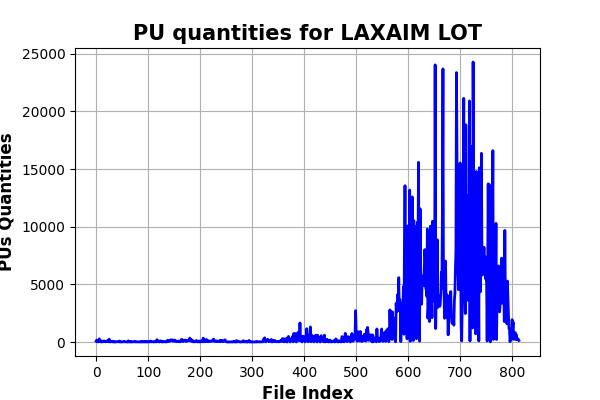

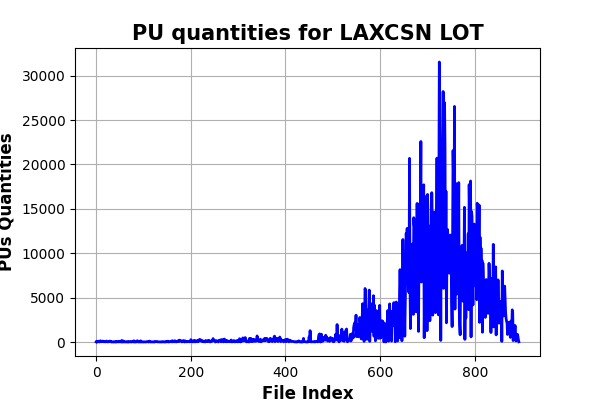

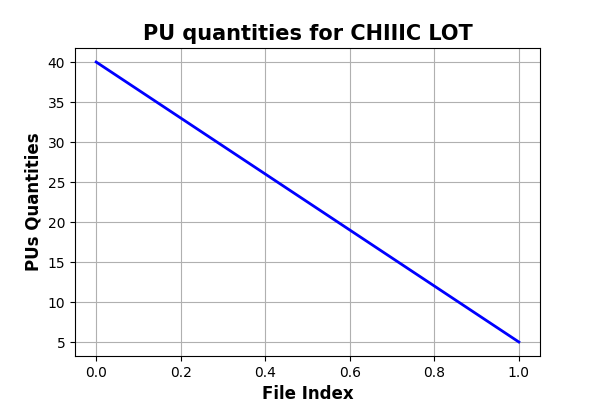

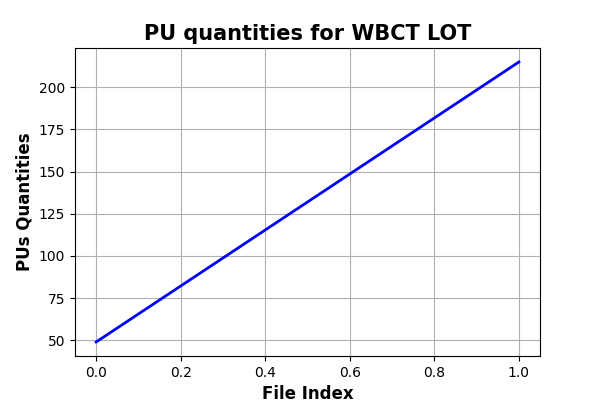

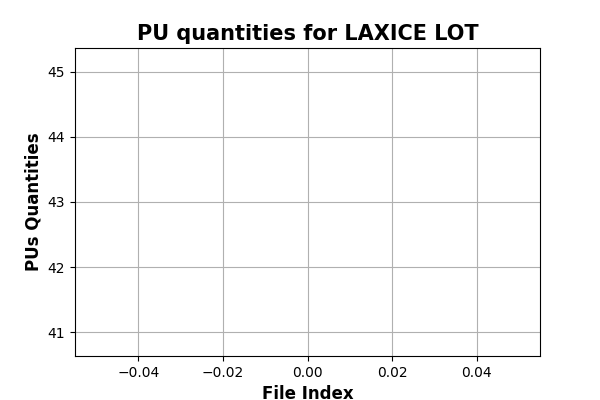

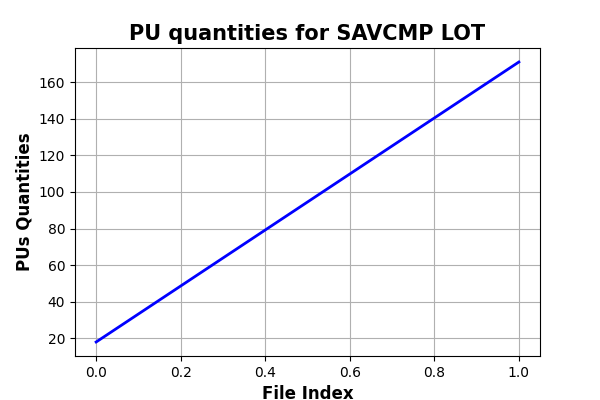

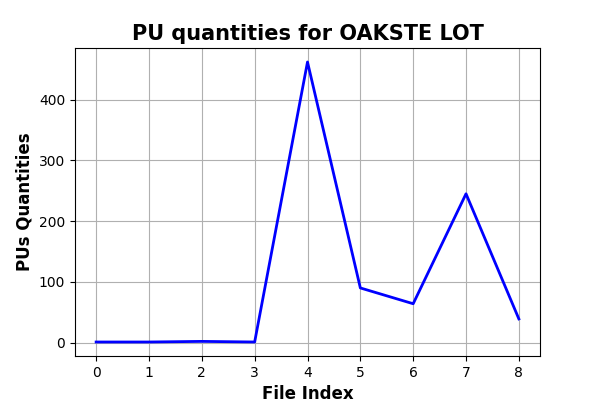

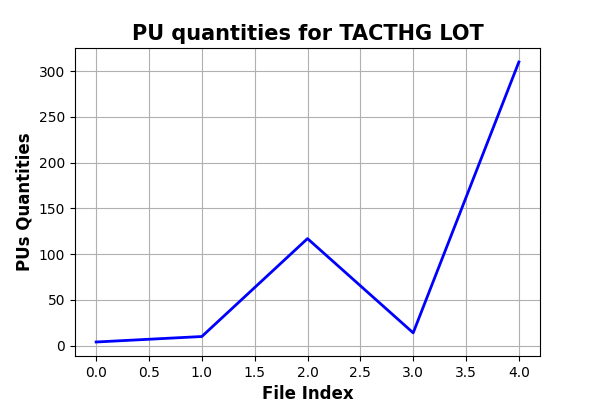

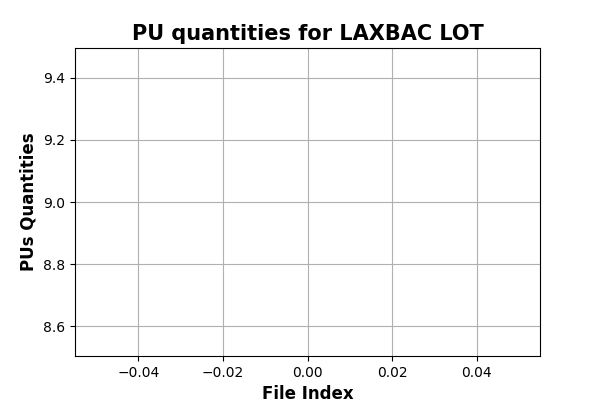

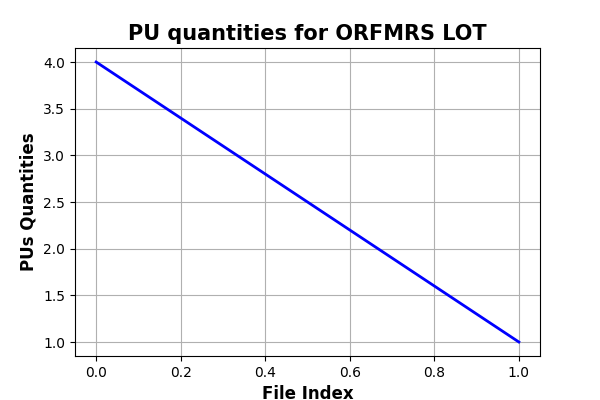

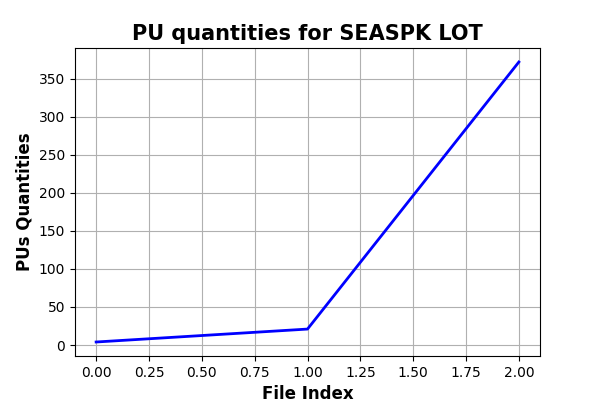

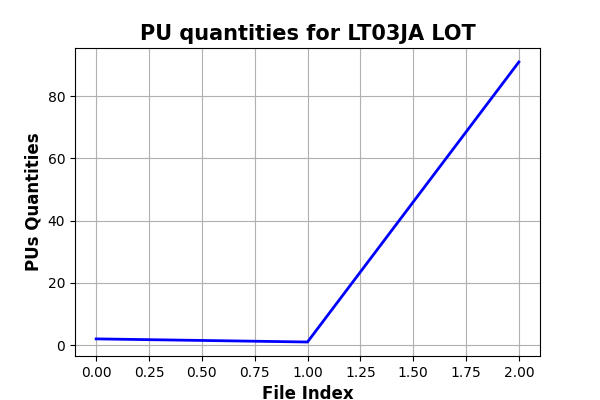

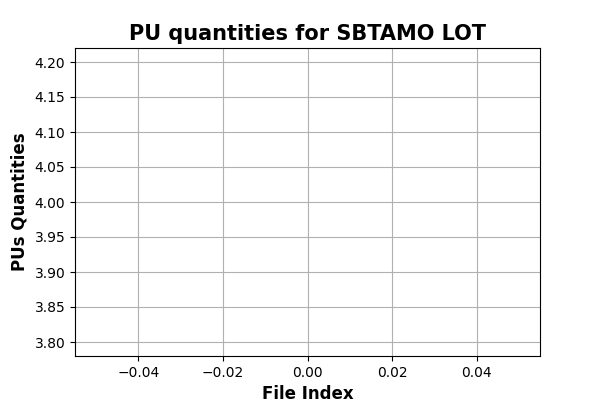

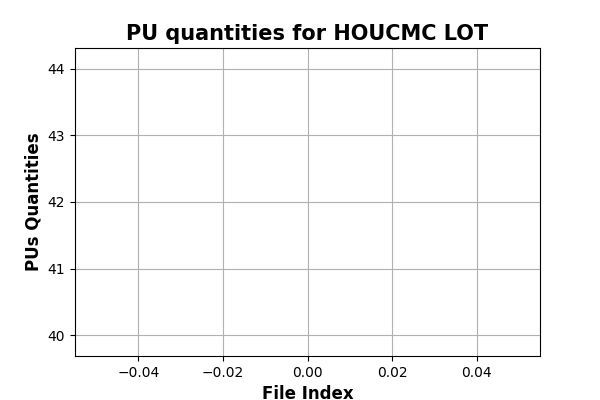

In [8]:
# Display results

# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

for pu_lot in PUs_Quants_per_Day_by_LOT.keys():
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(np.arange(0, len(PUs_Quants_per_Day_by_LOT[pu_lot])), PUs_Quants_per_Day_by_LOT[pu_lot], color='b', linewidth=2)
    ax.set_xlabel('File Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('PUs Quantities', fontsize=12, fontweight='bold')
    ax.set_title(f'PU quantities for {pu_lot} LOT', fontsize=15, fontweight='bold')
    ax.grid()

    plt.show()

In [7]:
# ACCURACY check - check whether the method of extrapolation of the moving window for pickup prediction for each lot
%matplotlib inline

Generate_DOCX_Report = 1
Extrapolation_Window_Size = 5
PU_Moving_AVG_REP_Extrapolated = {}
X_Values = []
Steps_2_Extrapolate = 1
Display_Factor = 2


for return_lot in PUs_Quants_per_Day_by_LOT.keys():
    PUs_Sums = PUs_Quants_per_Day_by_LOT[return_lot]

    for ii in range(len(PUs_Sums)):
        print(f'Analyzing extrapolation ACCURACY for lot {return_lot} - sample {ii+1} out of {len(PUs_Sums)} ({int(100*(ii+1)/len(PUs_Sums))}%)', end='\r')
        try:
            PU_Moving_AVG_REP_Extrapolated[return_lot]
        except:
            PU_Moving_AVG_REP_Extrapolated[return_lot] = [[], [], []]       # [File_Indexes (x_values), Extrapolated values, Error]

        if ii>=Extrapolation_Window_Size:
            # Generate the extrapolated value
            PU_Num_Pred = Flexivan_Prediction_Package.auto_extrapolate(PUs_Quants_per_Day_by_LOT[return_lot][(ii-Extrapolation_Window_Size):ii], \
                Steps_2_Extrapolate)

            GT = PUs_Quants_per_Day_by_LOT[return_lot][ii]          # Ground truth
            Error = 100 * (PU_Num_Pred - GT) / GT
            
            PU_Moving_AVG_REP_Extrapolated[return_lot][0].append(ii)
            PU_Moving_AVG_REP_Extrapolated[return_lot][1].append(PU_Num_Pred)
            PU_Moving_AVG_REP_Extrapolated[return_lot][2].append(Error)
            
# Initialize document
if Generate_DOCX_Report:
    doc = Document()
    doc.add_heading('Pickups Prediction Accuracy Report', 1)
    p = doc.add_paragraph('This document contains the results of applying the moving window extrapolation method for the prediction \
        of pickups for future dates for each lot separately. This method was used because the data cannot be used for pickups prediction it already\
            assumes that a chassis loan was performed. The future pickups prediction problem answers a different question entirely - whether there\
                will be a pickup or not. This method used a comb of last values of sums of pickups from a lot and extrapolates using an automatic\
                    algorithm that optimizes the least error extrapolation model (linear, quadratic or cubic).')
    p.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

    p = doc.add_paragraph('\nThe results show the extrapolated (predicted) value and the real value in Blue and Green, and the error rate of each\
        sample in Red in other coordinates set. Each LOT''s results are shown in a separate sub-section of this document')
    p.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

PUs_Total_Sum = sum(PUs_SUMS_DICT.values())

# Display results
for return_lot in PU_Moving_AVG_REP_Extrapolated.keys():
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(PU_Moving_AVG_REP_Extrapolated[return_lot][0], PU_Moving_AVG_REP_Extrapolated[return_lot][1], color='b', linewidth=2, label='Extrapolated PUs')
    ax.plot(np.arange(Extrapolation_Window_Size, len(PUs_Quants_per_Day_by_LOT[return_lot])), \
        PUs_Quants_per_Day_by_LOT[return_lot][Extrapolation_Window_Size:len(PUs_Quants_per_Day_by_LOT[return_lot])], color='g', linewidth=2, label='Ground Truth')

    AVG_ERROR = np.round(np.mean(np.array(PU_Moving_AVG_REP_Extrapolated[return_lot][2])), 2)
    ax2 = ax.twinx()
    ax2.plot(PU_Moving_AVG_REP_Extrapolated[return_lot][0], PU_Moving_AVG_REP_Extrapolated[return_lot][2], color='r', linewidth=2, label=f'Error % ({AVG_ERROR}% AVG)')

    ax.set_xlabel('File Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('PUs Quantities', fontsize=12, fontweight='bold')
    ax.set_title(f'Extrapolated PUs Quantities {return_lot} LOT\nvs. Ground Truth', fontsize=15, fontweight='bold')
    ax2.set_ylabel('Error %', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    ax.grid()

    if Generate_DOCX_Report:
        Percentage = 100 * PUs_SUMS_DICT[return_lot] / PUs_Total_Sum
        doc.add_heading(f'\n\nPickup Prediction Results for LOT {return_lot}\n', level=2)
        doc.add_paragraph(f'This lot has {Flexivan_Prediction_Package.Comma_Separation_Num_String(PUs_SUMS_DICT[return_lot])} pickups from it ({np.round(Percentage, 1)}% of total data)')

        plt.savefig("TEMP_PU_PRED_RESULTS.png")
        p = doc.add_paragraph()
        run = p.add_run()
        doc.add_picture('TEMP_PU_PRED_RESULTS.png', width=Inches(4))
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER

    plt.show()

# remove temp image files
if Generate_DOCX_Report:
    doc.save('Pickup_Accuracy_Report_by_LOT.docx')
    os.remove('TEMP_PU_PRED_RESULTS.png')


AttributeError: module 'Flexivan_Prediction_Package' has no attribute 'auto_extrapolate'

In [ ]:
# Evaluate moving average accuracy (plot on plot)